# 02a Descarga de POI y capas de contexto (Colab)

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Este notebook **solo descarga y respalda** los datos de OpenStreetMap (requiere acceso a la API Overpass, que suele fallar desde la red local; por eso se ejecuta en Colab). La integración al grafo (punto representativo, nodo más cercano, distancia de snap) se hace después, en local y sin red, en `02b_poi_integracion`.

**Qué se descarga**

| Capa | Etiquetas OSM | Uso |
|---|---|---|
| `salud` | `amenity=hospital/clinic`, `healthcare=hospital/clinic/centre` | Equipamiento (tema 4) |
| `educacion` | `amenity=school` | Equipamiento (tema 4) |
| `mercados` | `amenity=marketplace`, `shop=supermarket` | Equipamiento (tema 4) |
| `parques` | `leisure=park` | Contexto |
| `barreras` | `railway=rail`, `waterway=river/canal`, `highway=motorway/trunk` | Contexto: barreras físicas para la discusión |

**Zona de descarga:** los dos distritos con un buffer de `POI_BUFFER_M` = 1 200 m (lo que se camina en 15 min a 4.8 km/h), mayor que el del grafo (300 m). Así se puede decidir después si se incluye el equipamiento cercano a los límites, o si conviene ampliar el grafo.

**Al terminar**, copiar `poi_osm.gpkg` y `poi_descarga_log.json` a `data/raw/` del repositorio.

## 1. Configuración, semilla y versiones

In [1]:
import sys, json, time, hashlib, platform, datetime, subprocess, importlib.util
from pathlib import Path

# En Colab osmnx no viene instalado
if importlib.util.find_spec("osmnx") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "osmnx"])

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import shapely
import osmnx as ox
import matplotlib.pyplot as plt

try:
    sys.path.insert(0, str(Path.cwd().parent))
    from src import config as cfg
    DATA_RAW = cfg.DATA_RAW
except Exception:
    # Colab sin el repositorio: mismos valores que src/config.py
    class cfg:
        SEED = 42
        PLACES = ["Miraflores, Lima, Peru", "San Juan de Miraflores, Lima, Peru"]
        DISTRICT_LABELS = ["Miraflores", "San Juan de Miraflores"]
        BUFFER_M = 300
        CRS_METRIC = "EPSG:32718"
    DATA_RAW = Path("data/raw")

POI_BUFFER_M = getattr(cfg, "POI_BUFFER_M", 1200)
DATA_RAW.mkdir(parents=True, exist_ok=True)

np.random.seed(cfg.SEED)
ox.settings.timeout = 300
ox.settings.requests_timeout = 120
ox.settings.use_cache = True
ox.settings.log_console = False

versiones = {
    "python": platform.python_version(),
    "osmnx": ox.__version__,
    "networkx": nx.__version__,
    "geopandas": gpd.__version__,
    "shapely": shapely.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
versiones

{'python': '3.13.15',
 'osmnx': '2.1.1',
 'networkx': '3.6.1',
 'geopandas': '1.1.4',
 'shapely': '2.1.2',
 'numpy': '2.1.3',
 'pandas': '2.2.3'}

## 2. Zona de descarga

Los buffers se calculan en UTM (metros), nunca en grados.

Distritos: 31.5 km² | zona del grafo (+300 m): 45.4 km² | zona POI (+1200 m): 90.6 km²


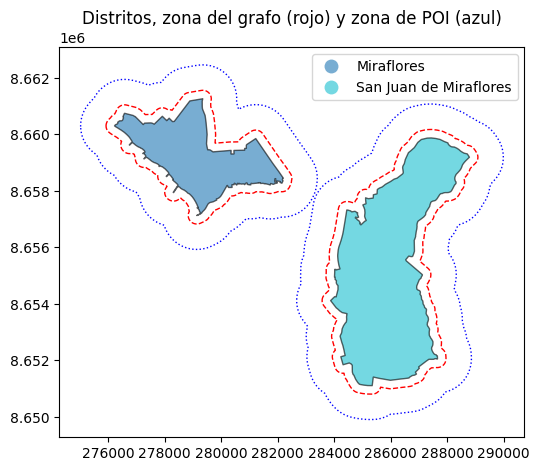

In [2]:
limites = ox.geocode_to_gdf(cfg.PLACES)
limites["distrito"] = cfg.DISTRICT_LABELS
limites_utm = limites.to_crs(cfg.CRS_METRIC)

union_utm = limites_utm.geometry.union_all()
zona_grafo = union_utm.buffer(cfg.BUFFER_M)       # misma zona que el grafo
zona_poi = union_utm.buffer(POI_BUFFER_M)         # zona ampliada para POI
poligono_poi = gpd.GeoSeries([zona_poi], crs=cfg.CRS_METRIC).to_crs(4326).iloc[0]

print(f"Distritos: {union_utm.area/1e6:.1f} km² | zona del grafo (+{cfg.BUFFER_M} m): {zona_grafo.area/1e6:.1f} km² | zona POI (+{POI_BUFFER_M} m): {zona_poi.area/1e6:.1f} km²")

ax = limites_utm.plot(column="distrito", alpha=0.6, edgecolor="k", legend=True, figsize=(6, 6))
gpd.GeoSeries([zona_grafo], crs=cfg.CRS_METRIC).boundary.plot(ax=ax, color="r", ls="--", lw=1)
gpd.GeoSeries([zona_poi], crs=cfg.CRS_METRIC).boundary.plot(ax=ax, color="b", ls=":", lw=1)
ax.set_title("Distritos, zona del grafo (rojo) y zona de POI (azul)")
plt.show()

## 3. Definición de capas

In [3]:
CAPAS = {
    "salud":     {"amenity": ["hospital", "clinic"], "healthcare": ["hospital", "clinic", "centre"]},
    "educacion": {"amenity": ["school"]},
    "mercados":  {"amenity": ["marketplace"], "shop": ["supermarket"]},
    "parques":   {"leisure": ["park"]},
    "barreras":  {"railway": ["rail"], "waterway": ["river", "canal"], "highway": ["motorway", "trunk"]},
}
# Se guardan solo las columnas útiles (OSM trae cientos de etiquetas, incluidas listas que GeoPackage no admite)
COLUMNAS = ["name", "amenity", "healthcare", "shop", "leisure", "railway", "waterway", "highway",
            "operator", "operator:type", "emergency", "beds", "addr:street", "access", "geometry"]
CAT_COLS = ["amenity", "healthcare", "shop", "leisure", "railway", "waterway", "highway"]

## 4. Descarga

Overpass puede tardar o rechazar conexiones; cada capa se reintenta con pausa. Se registra el momento de la descarga.

In [4]:
def descargar(tags, intentos=6):
    for i in range(1, intentos + 1):
        try:
            return ox.features_from_polygon(poligono_poi, tags)
        except ox.errors.InsufficientResponseError:
            return gpd.GeoDataFrame(geometry=[], crs=4326)   # sin resultados
        except Exception as e:
            print(f"   intento {i} fallido: {type(e).__name__}")
            if i == intentos:
                raise
            time.sleep(10)

momento = datetime.datetime.now().astimezone()
capas = {}
for nombre, tags in CAPAS.items():
    bruto = descargar(tags)
    print(f"{nombre}: {len(bruto)} elementos")
    capas[nombre] = bruto

salud: 126 elementos
educacion: 748 elementos
mercados: 205 elementos
parques: 971 elementos
barreras: 180 elementos


## 5. Preparación de las capas

- Se conserva el identificador OSM (`element`, `id`) y las columnas útiles.
- `categoria`: valor de la etiqueta principal (p. ej. `hospital`, `school`, `supermarket`).
- `zona`: dónde cae cada elemento (por su punto representativo): dentro de un distrito, en el buffer del grafo (≤ 300 m) o en la zona ampliada (300–1 200 m).

In [5]:
def preparar(gdf):
    if gdf.empty:
        return gdf
    gdf = gdf.reset_index()                       # element, id
    cols = [c for c in ["element", "id"] + COLUMNAS if c in gdf.columns]
    gdf = gdf[cols].copy()
    cats = [c for c in CAT_COLS if c in gdf.columns]
    gdf["categoria"] = gdf[cats].bfill(axis=1).iloc[:, 0]
    gdf["tipo_geom"] = gdf.geom_type

    pts = gpd.GeoSeries(gdf.geometry, crs=4326).to_crs(cfg.CRS_METRIC).representative_point()
    p = gpd.GeoDataFrame(geometry=pts)
    j = gpd.sjoin(p, limites_utm[["distrito", "geometry"]], how="left", predicate="within")
    j = j[~j.index.duplicated(keep="first")]["distrito"]
    zona = pd.Series(np.where(pts.within(zona_grafo), "Buffer (≤ 300 m)", "Zona ampliada (300–1200 m)"), index=gdf.index)
    zona[j.notna()] = j[j.notna()]
    gdf["zona"] = zona.values
    return gdf

capas = {n: preparar(g) for n, g in capas.items()}
resumen = pd.concat(
    {n: g["zona"].value_counts() for n, g in capas.items() if not g.empty}, axis=1
).fillna(0).astype(int)
resumen.loc["TOTAL"] = resumen.sum()
resumen

,salud,educacion,mercados,parques,barreras
zona,,,,,
Zona ampliada (300–1200 m),52,331,103,458,43
Miraflores,30,63,30,114,63
San Juan de Miraflores,24,292,51,271,26
Buffer (≤ 300 m),20,62,21,128,48
TOTAL,126,748,205,971,180


In [6]:
# Detalle por categoría en las capas de equipamiento
for nombre in ("salud", "educacion", "mercados"):
    g = capas[nombre]
    if g.empty:
        print(f"{nombre}: sin elementos\n")
        continue
    print(f"--- {nombre}: {len(g)} elementos | geometrías: {g['tipo_geom'].value_counts().to_dict()}")
    print(pd.crosstab(g["categoria"], g["zona"]).to_string(), "\n")

--- salud: 126 elementos | geometrías: {'Polygon': 78, 'Point': 47, 'MultiPolygon': 1}
zona       Buffer (≤ 300 m)  Miraflores  San Juan de Miraflores  Zona ampliada (300–1200 m)
categoria                                                                                  
centre                    0           0                       1                           0
clinic                   19          26                      20                          46
hospital                  1           4                       3                           6 

--- educacion: 748 elementos | geometrías: {'Point': 449, 'Polygon': 299}
zona       Buffer (≤ 300 m)  Miraflores  San Juan de Miraflores  Zona ampliada (300–1200 m)
categoria                                                                                  
school                   62          63                     292                         331 

--- mercados: 205 elementos | geometrías: {'Polygon': 152, 'Point': 52, 'MultiPolygon': 1}
zona    

## 6. Respaldo en disco y registro de reproducibilidad

Cada capa se guarda en `poi_osm.gpkg`, separada por tipo de geometría (`<capa>_point`, `<capa>_polygon`, `<capa>_linestring`…), porque un mismo layer GeoPackage no mezcla geometrías de forma fiable. El log guarda fecha, etiquetas, buffers, versiones, conteos y SHA-256.

In [7]:
ruta_gpkg = DATA_RAW / "poi_osm.gpkg"
ruta_log = DATA_RAW / "poi_descarga_log.json"
if ruta_gpkg.exists():
    ruta_gpkg.unlink()

capas_guardadas = {}
for nombre, g in capas.items():
    for tipo, sub in g.groupby("tipo_geom"):
        layer = f"{nombre}_{tipo.lower()}"
        sub.drop(columns="tipo_geom").to_file(ruta_gpkg, layer=layer, driver="GPKG")
        capas_guardadas[layer] = len(sub)

def sha256(ruta):
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(1 << 20), b""):
            h.update(bloque)
    return h.hexdigest()

log = {
    "fecha_descarga": momento.isoformat(timespec="seconds"),
    "consulta": {
        "funcion": "ox.features_from_polygon",
        "lugares": cfg.PLACES,
        "buffer_poi_m": POI_BUFFER_M,
        "buffer_grafo_m": cfg.BUFFER_M,
        "crs_buffer": cfg.CRS_METRIC,
        "etiquetas": CAPAS,
    },
    "versiones": versiones,
    "resultado": {
        "elementos_por_capa": {n: int(len(g)) for n, g in capas.items()},
        "layers_gpkg": capas_guardadas,
        "elementos_por_capa_y_zona": {n: g["zona"].value_counts().to_dict() for n, g in capas.items() if not g.empty},
        "archivo": ruta_gpkg.name,
        "sha256": sha256(ruta_gpkg),
    },
}
ruta_log.write_text(json.dumps(log, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(log["resultado"], indent=2, ensure_ascii=False))

{
  "elementos_por_capa": {
    "salud": 126,
    "educacion": 748,
    "mercados": 205,
    "parques": 971,
    "barreras": 180
  },
  "layers_gpkg": {
    "salud_multipolygon": 1,
    "salud_point": 47,
    "salud_polygon": 78,
    "educacion_point": 449,
    "educacion_polygon": 299,
    "mercados_multipolygon": 1,
    "mercados_point": 52,
    "mercados_polygon": 152,
    "parques_multipolygon": 3,
    "parques_point": 4,
    "parques_polygon": 964,
    "barreras_linestring": 180
  },
  "elementos_por_capa_y_zona": {
    "salud": {
      "Zona ampliada (300–1200 m)": 52,
      "Miraflores": 30,
      "San Juan de Miraflores": 24,
      "Buffer (≤ 300 m)": 20
    },
    "educacion": {
      "Zona ampliada (300–1200 m)": 331,
      "San Juan de Miraflores": 292,
      "Miraflores": 63,
      "Buffer (≤ 300 m)": 62
    },
    "mercados": {
      "Zona ampliada (300–1200 m)": 103,
      "San Juan de Miraflores": 51,
      "Miraflores": 30,
      "Buffer (≤ 300 m)": 21
    },
    "parqu

## 7. Vista rápida de control

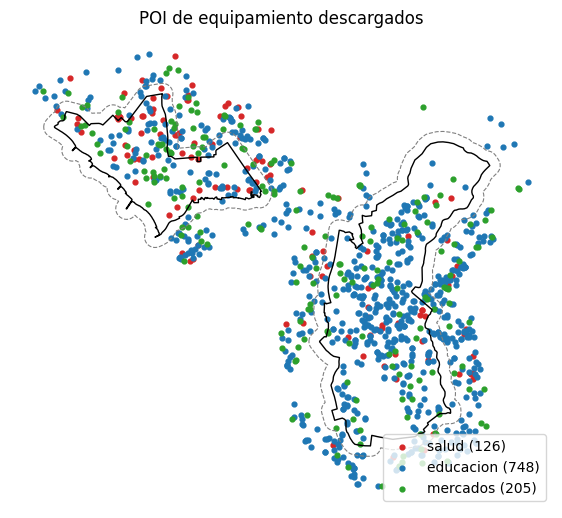

In [8]:
colores = {"salud": "#d62728", "educacion": "#1f77b4", "mercados": "#2ca02c"}
fig, ax = plt.subplots(figsize=(7, 7))
limites_utm.boundary.plot(ax=ax, color="k", lw=1)
gpd.GeoSeries([zona_grafo], crs=cfg.CRS_METRIC).boundary.plot(ax=ax, color="gray", ls="--", lw=0.8)
for nombre, color in colores.items():
    g = capas[nombre]
    if g.empty:
        continue
    pts = gpd.GeoSeries(g.geometry, crs=4326).to_crs(cfg.CRS_METRIC).representative_point()
    pts.plot(ax=ax, color=color, markersize=12, label=f"{nombre} ({len(g)})")
ax.legend(loc="lower right")
ax.set_title("POI de equipamiento descargados")
ax.set_axis_off()
plt.show()

## 8. Descarga de los archivos (solo Colab)

Copiar `poi_osm.gpkg` y `poi_descarga_log.json` a `data/raw/` del repositorio.

In [9]:
try:
    from google.colab import files
    for ruta in (ruta_gpkg, ruta_log):
        files.download(str(ruta))
except ImportError:
    print("Fuera de Colab: los archivos ya están en", DATA_RAW.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>